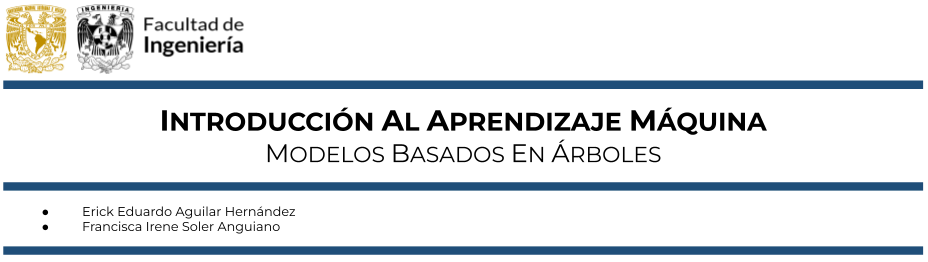

**Repositorio oficial del libro**

https://github.com/ErickEduardoAH/book-resources

**Licencia**

MIT License

---
Este notebook forma parte del material oficial que acompaña al libro *Introducción al Aprendizaje Máquina: Modelos Basados en Árboles*. Su objetivo es reproducir y ampliar los ejemplos desarrollados en el texto mediante implementaciones en Python completamente reproducibles.
___
#### Notebook 5.3 — Implementación: Ajuste de un árbol de clasificación
___

### Preparación del entorno de trabajo

En esta celda se importan las bibliotecas necesarias para reproducir el ajuste de un árbol de clasificación. 
Se cargan herramientas para manipulación de datos, visualización, lectura de archivos locales y construcción del modelo con `scikit-learn`. 
También se fija el estilo gráfico `ggplot`, de modo que las tablas y visualizaciones mantengan una presentación homogénea a lo largo del notebook.


In [25]:
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('ggplot')

### Carga del conjunto German Credit

Se carga el conjunto **German Credit**, utilizado para ilustrar un problema de clasificación binaria asociado al riesgo crediticio. 
La variable objetivo `class` distingue entre créditos clasificados como `good` y `bad`. 
La transposición de las primeras observaciones permite inspeccionar con mayor comodidad los nombres de las variables y los tipos de valores presentes en el conjunto.


In [8]:
features = [
    "duration",
    "credit_amount",
    "age",
    "checking_status",
    "employment",
    "housing",
    "purpose",
    "installment_commitment",
    "existing_credits",
    "job",
    "num_dependents"
]

data_paths = [Path("datos") / "credit-g.csv", Path("..") / "datos" / "credit-g.csv"]
data_path = next(path for path in data_paths if path.exists())
data_df = pd.read_csv(data_path)[features+["class"]]
display(data_df)

,duration,credit_amount,age,checking_status,employment,housing,purpose,installment_commitment,existing_credits,job,num_dependents,class
0,6,1169,67,<0,>=7,own,radio/tv,4,2,skilled,1,good
1,48,5951,22,0<=X<200,1<=X<4,own,radio/tv,2,1,skilled,1,bad
2,12,2096,49,no checking,4<=X<7,own,education,2,1,unskilled resident,2,good
3,42,7882,45,<0,4<=X<7,for free,furniture/equipment,2,1,skilled,2,good
4,24,4870,53,<0,1<=X<4,for free,new car,3,2,skilled,2,bad
...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,1736,31,no checking,4<=X<7,own,furniture/equipment,3,1,unskilled resident,1,good
996,30,3857,40,<0,1<=X<4,own,used car,4,1,high qualif/self emp/mgmt,1,good
997,12,804,38,no checking,>=7,own,radio/tv,4,1,skilled,1,good
998,45,1845,23,<0,1<=X<4,for free,radio/tv,4,1,skilled,1,bad


### Codificación de variables categóricas

El árbol de clasificación de `scikit-learn` requiere una matriz numérica de predictores. 
Por ello, las variables categóricas se transforman mediante codificación **one-hot**, creando una columna indicadora por categoría, mientras que las variables numéricas pasan sin modificación. 
Finalmente, la respuesta `class` se convierte a una variable binaria, donde la clase `good` se codifica como 1 y la clase `bad` como 0.


In [4]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Variables categóricas y numéricas
categoricals = [
    "checking_status",
    "employment",
    "housing",
    "purpose"
]

numericals = [
    "duration",
    "credit_amount",
    "age",
    "installment_commitment",
    "existing_credits",
    "num_dependents"
]

# Encoder One Hot
ohe = OneHotEncoder(
    drop=None,           # no elimina categorías
    sparse_output=False, # devuelve DataFrame usable
    handle_unknown="ignore"
)

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, categoricals),
        ("num", "passthrough", numericals)
    ]
)

# Aplicar transformación
X_transformed = preprocessor.fit_transform(data_df)

# Obtener nombres de columnas
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categoricals)

# Unir nombres
all_features = list(cat_features) + numericals

# Convertir a DataFrame
X = pd.DataFrame(X_transformed, columns=all_features)
y = (data_df["class"] == "good").astype(int)

display(X)
display(y)

,checking_status_0<=X<200,checking_status_<0,checking_status_>=200,checking_status_no checking,employment_1<=X<4,employment_4<=X<7,employment_<1,employment_>=7,employment_unemployed,housing_for free,...,purpose_radio/tv,purpose_repairs,purpose_retraining,purpose_used car,duration,credit_amount,age,installment_commitment,existing_credits,num_dependents
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,1169.0,67.0,4.0,2.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,48.0,5951.0,22.0,2.0,1.0,1.0
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12.0,2096.0,49.0,2.0,1.0,2.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,42.0,7882.0,45.0,2.0,1.0,2.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,24.0,4870.0,53.0,3.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12.0,1736.0,31.0,3.0,1.0,1.0
996,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,30.0,3857.0,40.0,4.0,1.0,1.0
997,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,12.0,804.0,38.0,4.0,1.0,1.0
998,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,45.0,1845.0,23.0,4.0,1.0,1.0


0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: class, Length: 1000, dtype: int64

### Separación entrenamiento-prueba y trayectoria de poda

Antes de elegir el tamaño final del árbol, se separa una muestra de prueba estratificada para evaluar el desempeño fuera de muestra. La estratificación conserva la proporción de créditos `good` y `bad` en ambos subconjuntos. Después se ajusta un árbol grande, sin imponer una profundidad máxima, para obtener la trayectoria de poda por costo-complejidad. Los valores `ccp_alpha` representan distintos niveles de penalización: valores pequeños permiten árboles más grandes y valores más altos producen árboles más simples.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Árbol grande inicial
full_tree = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print("Número de alphas encontrados:", len(ccp_alphas))
print(ccp_alphas[:10])

Número de alphas encontrados: 78
[0.         0.00231794 0.00257831 0.00278581 0.0028558  0.00285714
 0.00285714 0.00285714 0.00285714 0.00285714]


### Validación cruzada para cada valor de alpha

La poda por costo-complejidad requiere decidir qué penalización produce el mejor balance entre ajuste y generalización. Para ello se evalúa cada `ccp_alpha` mediante validación cruzada estratificada de 5 folds. En cada fold se entrena el árbol con un subconjunto de los datos de entrenamiento y se valida en la parte restante, preservando la proporción de clases. Se registran el AUC y la exactitud promedio junto con su variabilidad, porque en clasificación interesa tanto la tasa de aciertos como la capacidad del modelo para ordenar correctamente las observaciones positivas y negativas.


In [ ]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        criterion="entropy",
        random_state=42,
        ccp_alpha=alpha
    )

    auc_scores = cross_val_score(
        clf, X_train, y_train,
        cv=cv,
        scoring="roc_auc"
    )

    acc_scores = cross_val_score(
        clf, X_train, y_train,
        cv=cv,
        scoring="accuracy"
    )

    rows.append({
        "ccp_alpha": alpha,
        "cv_auc_mean": auc_scores.mean(),
        "cv_auc_std": auc_scores.std(ddof=1),
        "cv_acc_mean": acc_scores.mean(),
        "cv_acc_std": acc_scores.std(ddof=1)
    })

cv_results = pd.DataFrame(rows)
cv_results.sort_values("ccp_alpha", inplace=True)
cv_results.reset_index(drop=True, inplace=True)
display(cv_results.head(10))

,ccp_alpha,cv_auc_mean,cv_auc_std,cv_acc_mean,cv_acc_std
0,0.000000,0.621769,0.037077,0.68,0.028302
1,0.002318,0.621769,0.037077,0.68,0.028302
2,0.002578,0.623008,0.037031,0.68,0.028302
3,0.002786,0.623008,0.037031,0.68,0.028302
4,0.002856,0.623008,0.037031,0.68,0.028302
5,0.002857,0.623008,0.037031,0.68,0.028302
6,0.002857,0.623008,0.037031,0.68,0.028302
7,0.002857,0.623008,0.037031,0.68,0.028302
8,0.002857,0.623008,0.037031,0.68,0.028302
9,0.002857,0.623008,0.037031,0.68,0.028302


### Selección del mejor alpha y regla 1-SE

Primero se identifica el `ccp_alpha` con mayor AUC promedio en validación cruzada. Luego se aplica la regla de una desviación estándar, o regla 1-SE: en lugar de elegir necesariamente el árbol con el mejor promedio, se permite escoger un árbol más simple cuyo desempeño esté dentro del margen de error estándar del mejor modelo. Esta regla favorece modelos más parsimoniosos cuando la mejora del árbol más complejo no es claramente distinguible por validación cruzada.


In [11]:
best_idx = cv_results["cv_auc_mean"].idxmax()
best_alpha = cv_results.loc[best_idx, "ccp_alpha"]
best_auc = cv_results.loc[best_idx, "cv_auc_mean"]

print("Mejor ccp_alpha:", best_alpha)
print("Mejor AUC CV:", best_auc)

cv_results["cv_auc_se"] = cv_results["cv_auc_std"] / np.sqrt(cv.get_n_splits())

best_idx = cv_results["cv_auc_mean"].idxmax()
auc_max = cv_results.loc[best_idx, "cv_auc_mean"]
auc_se  = cv_results.loc[best_idx, "cv_auc_se"]

threshold = auc_max - auc_se

# Como queremos arboles mas simples, tomamos el alpha mas grande
# cuyo AUC aun este dentro de 1 SE del mejor
eligible = cv_results[cv_results["cv_auc_mean"] >= threshold]
alpha_1se = eligible["ccp_alpha"].max()

print("Alpha_max_auc:", cv_results.loc[best_idx, "ccp_alpha"])
print("Alpha_1se:", alpha_1se)
print("Threshold_1se:", threshold)


print("Mejor ccp_alpha:", best_alpha)
print("Mejor AUC CV:", best_auc)

pruned_tree_best_alpha = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    ccp_alpha=best_alpha
).fit(X_train, y_train)


pruned_tree_alpha_1se = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    ccp_alpha=alpha_1se
).fit(X_train, y_train)

Mejor ccp_alpha: 0.012905850359944487
Mejor AUC CV: 0.7154761904761905
Alpha_max_auc: 0.012905850359944487
Alpha_1se: 0.014288497812289566
Threshold_1se: 0.7057775189594199
Mejor ccp_alpha: 0.012905850359944487
Mejor AUC CV: 0.7154761904761905


### Métricas del árbol podado con mejor alpha

Con el `ccp_alpha` que maximiza el AUC promedio de validación cruzada se entrena un árbol final usando todos los datos de entrenamiento. Después se calculan sus predicciones de clase y sus probabilidades estimadas para entrenamiento y prueba. La exactitud resume la proporción de clasificaciones correctas, mientras que el AUC mide la capacidad del árbol para asignar mayor probabilidad a la clase positiva `good` que a la clase negativa `bad`. Comparar entrenamiento contra prueba ayuda a detectar si el desempeño se conserva fuera de muestra.


In [14]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve

# Predicciones
y_train_pred = pruned_tree_best_alpha.predict(X_train)
y_test_pred  = pruned_tree_best_alpha.predict(X_test)
y_train_prob = pruned_tree_best_alpha.predict_proba(X_train)[:, 1]
y_test_prob  = pruned_tree_best_alpha.predict_proba(X_test)[:, 1]

import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones
y_train_pred = pruned_tree_best_alpha.predict(X_train)
y_test_pred  = pruned_tree_best_alpha.predict(X_test)
y_train_prob = pruned_tree_best_alpha.predict_proba(X_train)[:, 1]
y_test_prob  = pruned_tree_best_alpha.predict_proba(X_test)[:, 1]

# Métricas
results = pd.DataFrame([
    {
        "fold": "Training",
        "Accuracy": accuracy_score(y_train, y_train_pred),
        "AUC": roc_auc_score(y_train, y_train_prob)
    },
    {
        "fold": "Test",
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "AUC": roc_auc_score(y_test, y_test_prob)
    }
])
display(results)

,fold,Accuracy,AUC
0,Training,0.755714,0.766603
1,Test,0.713333,0.702196


### Reporte de clasificación y matriz de confusión

El reporte de clasificación desagrega el desempeño por clase mediante precisión, recall y F1-score. Esto es importante porque la exactitud puede ocultar errores relevantes cuando las clases no tienen la misma frecuencia. La matriz de confusión muestra directamente cuántos créditos `bad` y `good` fueron clasificados correcta o incorrectamente, permitiendo distinguir falsos positivos y falsos negativos en el conjunto de prueba.



Reporte de clasificación - Test
              precision    recall  f1-score   support

           0       0.53      0.37      0.43        90
           1       0.76      0.86      0.81       210

    accuracy                           0.71       300
   macro avg       0.65      0.61      0.62       300
weighted avg       0.69      0.71      0.70       300



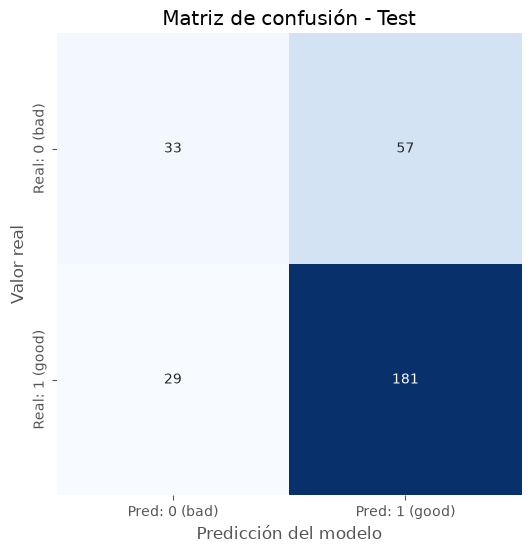

In [17]:
print("\nReporte de clasificación - Test")
print(classification_report(y_test, y_test_pred))

# Matriz de confusión con etiquetas
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm,annot=True,fmt="d",
    cmap="Blues",cbar=False,
    xticklabels=["Pred: 0 (bad)", "Pred: 1 (good)"],
    yticklabels=["Real: 0 (bad)", "Real: 1 (good)"]
)

plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Test")
plt.show()

### Curva ROC del árbol con mejor alpha

La curva ROC evalúa el clasificador para todos los posibles umbrales de decisión sobre la probabilidad estimada. En el eje vertical aparece la tasa de verdaderos positivos y en el eje horizontal la tasa de falsos positivos. La línea diagonal representa un clasificador sin capacidad discriminante. Al comparar las curvas de entrenamiento y prueba se observa si la capacidad de separación medida por el AUC se mantiene al pasar a datos no vistos.


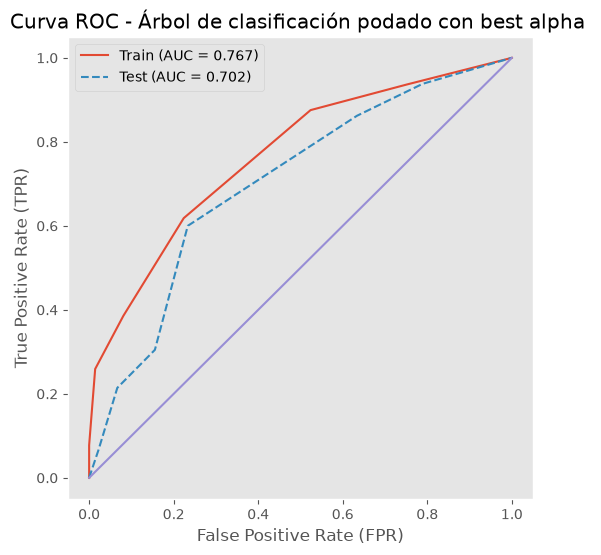

In [19]:
# Calcular FPR y TPR
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _   = roc_curve(y_test, y_test_prob)
auc_train = roc_auc_score(y_train, y_train_prob)
auc_test  = roc_auc_score(y_test, y_test_prob)

# Gráfica
plt.figure(figsize=(6,6))
plt.plot(fpr_train, tpr_train, label=f"Train (AUC = {auc_train:.3f})")
plt.plot(fpr_test, tpr_test, linestyle="--", label=f"Test (AUC = {auc_test:.3f})")

# Línea diagonal (modelo aleatorio)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC - Árbol de clasificación podado con best alpha ")
plt.legend()
plt.grid()
plt.show()

### Métricas del árbol seleccionado por la regla 1-SE

Ahora se evalúa el árbol podado con el `alpha_1se`. Este modelo suele ser más pequeño que el árbol con mejor AUC promedio, porque la regla 1-SE privilegia simplicidad siempre que la pérdida de desempeño esté dentro del margen de variabilidad de la validación cruzada. La comparación de exactitud y AUC en entrenamiento y prueba permite analizar si esa simplificación reduce sobreajuste sin deteriorar de forma importante la capacidad predictiva.


In [20]:
# Predicciones
y_train_pred = pruned_tree_alpha_1se.predict(X_train)
y_test_pred  = pruned_tree_alpha_1se.predict(X_test)
y_train_prob = pruned_tree_alpha_1se.predict_proba(X_train)[:, 1]
y_test_prob  = pruned_tree_alpha_1se.predict_proba(X_test)[:, 1]


# Métricas
results = pd.DataFrame([
    {
        "fold": "Training",
        "Accuracy": accuracy_score(y_train, y_train_pred),
        "AUC": roc_auc_score(y_train, y_train_prob)
    },
    {
        "fold": "Test",
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "AUC": roc_auc_score(y_test, y_test_prob)
    }
])

display(results)

,fold,Accuracy,AUC
0,Training,0.755714,0.766603
1,Test,0.713333,0.702196


### Reporte de clasificación del árbol 1-SE

Se repite el reporte de clasificación y la matriz de confusión para el árbol seleccionado por la regla 1-SE. Esta comparación permite ver si el modelo más simple conserva un comportamiento razonable por clase, especialmente en la identificación de créditos `bad`, donde los errores pueden ser más costosos que una lectura agregada de la exactitud.



Reporte de clasificación - Test
              precision    recall  f1-score   support

           0       0.53      0.37      0.43        90
           1       0.76      0.86      0.81       210

    accuracy                           0.71       300
   macro avg       0.65      0.61      0.62       300
weighted avg       0.69      0.71      0.70       300



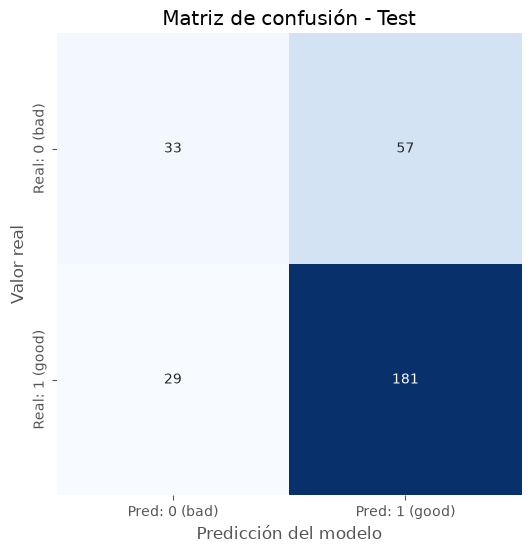

In [22]:
print("\nReporte de clasificación - Test")
print(classification_report(y_test, y_test_pred))

# Matriz de confusión con etiquetas
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm,annot=True,fmt="d",
    cmap="Blues",cbar=False,
    xticklabels=["Pred: 0 (bad)", "Pred: 1 (good)"],
    yticklabels=["Real: 0 (bad)", "Real: 1 (good)"]
)

plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Test")
plt.show()

### Curva ROC del árbol 1-SE

La curva ROC del árbol 1-SE muestra cómo cambia la sensibilidad y la tasa de falsos positivos al mover el umbral de clasificación. Al contrastarla con la curva del árbol de mejor AUC promedio, se observa si la simplificación obtenida por la regla 1-SE mantiene una capacidad discriminante similar en entrenamiento y prueba.


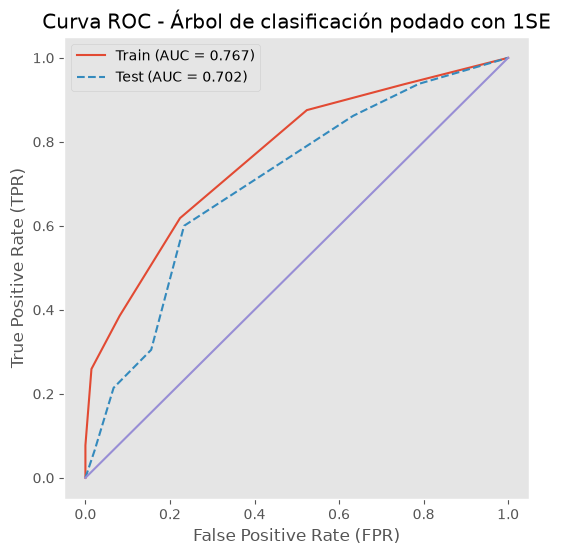

In [23]:
# Calcular FPR y TPR
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _   = roc_curve(y_test, y_test_prob)
auc_train = roc_auc_score(y_train, y_train_prob)
auc_test  = roc_auc_score(y_test, y_test_prob)

# Gráfica
plt.figure(figsize=(6,6))

plt.plot(fpr_train, tpr_train, label=f"Train (AUC = {auc_train:.3f})")
plt.plot(fpr_test, tpr_test, linestyle="--", label=f"Test (AUC = {auc_test:.3f})")

# Línea diagonal (modelo aleatorio)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC - Árbol de clasificación podado con 1SE")
plt.legend()
plt.grid()
plt.show()

### Estructura del árbol con mejor alpha

La visualización del árbol podado con el mejor `ccp_alpha` permite interpretar las particiones aprendidas: cada nodo contiene una regla de decisión, y las hojas resumen la clase asignada después de seguir esas reglas. El número de hojas y la profundidad cuantifican la complejidad del modelo, lo cual ayuda a conectar el desempeño predictivo con la interpretabilidad del árbol.


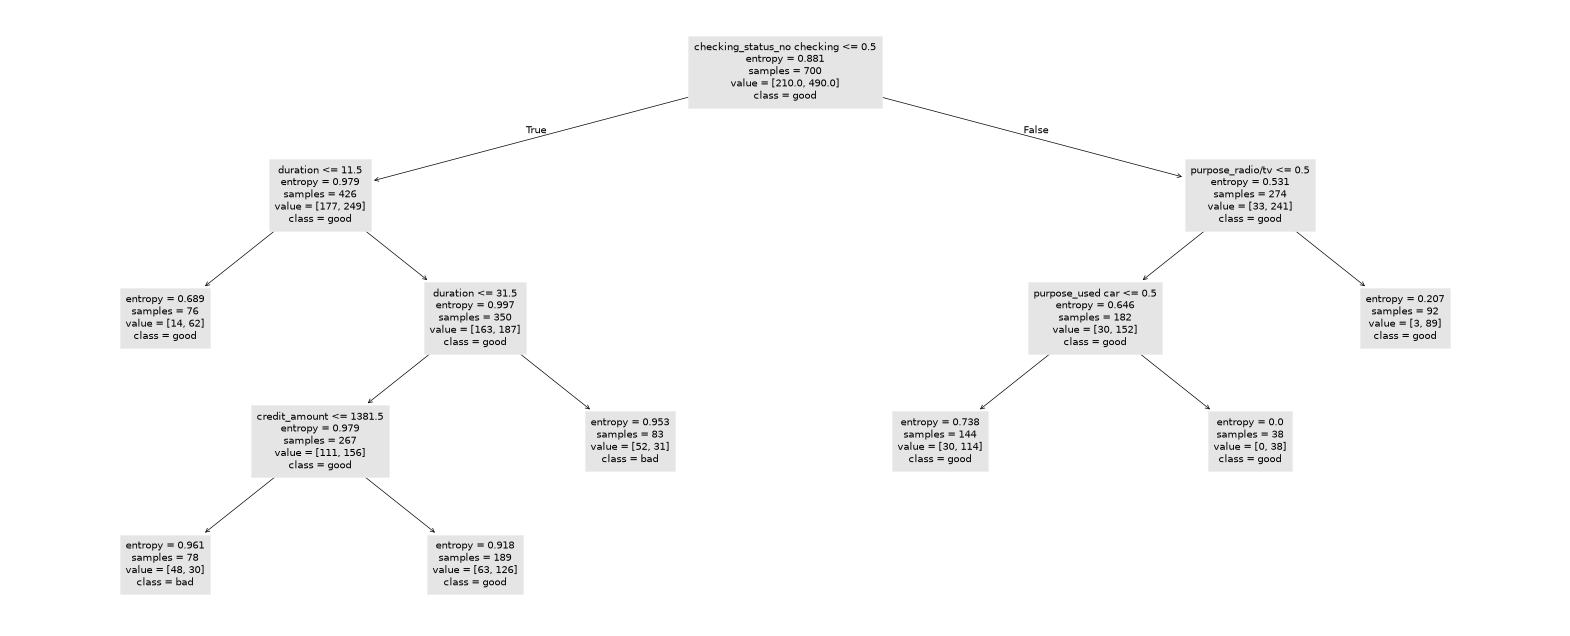

Número de hojas: 7
Profundidad: 4


In [26]:
plt.figure(figsize=(20,8))
plot_tree(
    pruned_tree_best_alpha,
    feature_names=all_features,
    class_names=["bad", "good"],
    fontsize=7
)
plt.show()

print("Número de hojas:", pruned_tree_best_alpha.get_n_leaves())
print("Profundidad:", pruned_tree_best_alpha.get_depth())

### Estructura del árbol seleccionado por 1-SE

Finalmente se visualiza el árbol elegido por la regla 1-SE. Al compararlo con el árbol de mejor AUC promedio, se puede observar el efecto práctico de aumentar la penalización por complejidad: menos hojas, menor profundidad y una estructura más fácil de explicar. Esta comparación refleja la idea central de la poda: aceptar un modelo ligeramente más simple cuando su desempeño fuera de muestra sigue siendo competitivo.


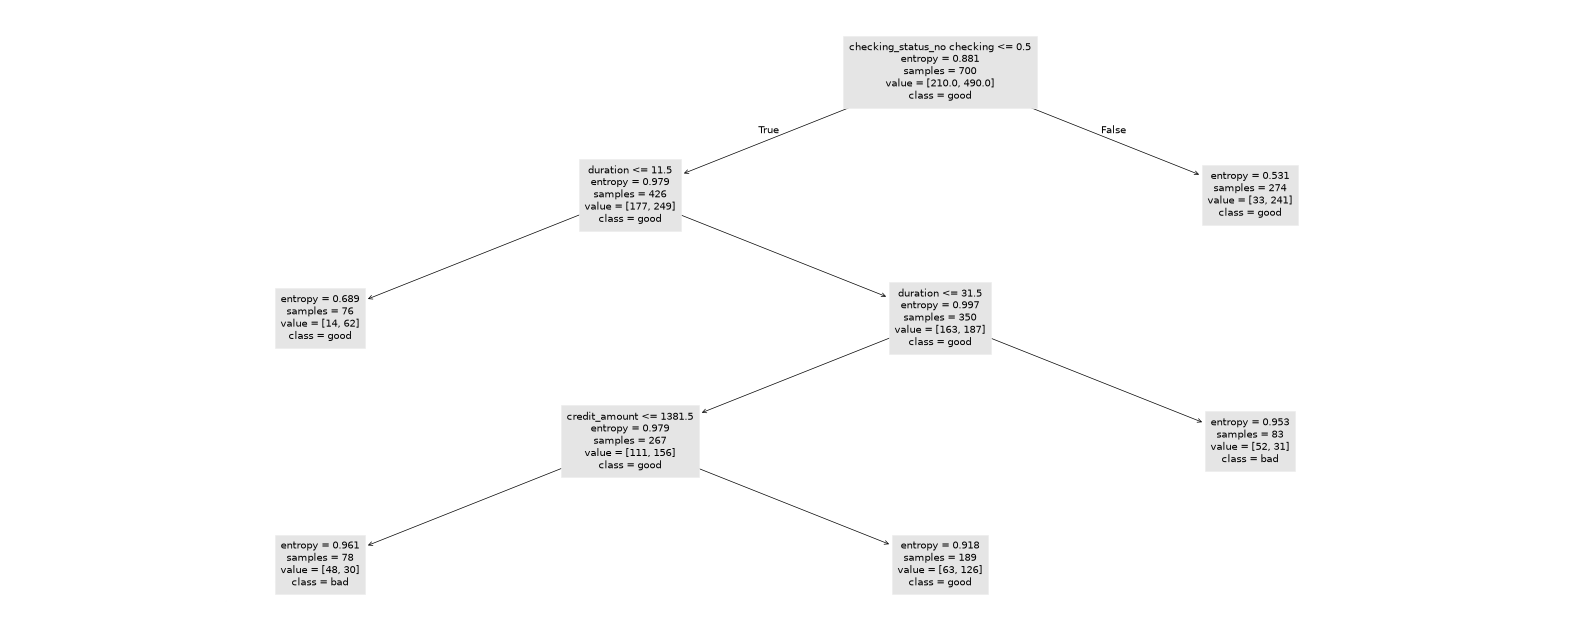

Número de hojas: 5
Profundidad: 4


In [27]:
plt.figure(figsize=(20,8))
plot_tree(
    pruned_tree_alpha_1se,
    feature_names=all_features,
    class_names=["bad", "good"],
    fontsize=7
)
plt.show()

print("Número de hojas:", pruned_tree_alpha_1se.get_n_leaves())
print("Profundidad:", pruned_tree_alpha_1se.get_depth())